# ¿Cuál es la mejor tarifa?

Trabajas como analista para el operador de telecomunicaciones Megaline. La empresa ofrece a sus clientes dos tarifas de prepago, Surf y Ultimate. El departamento comercial quiere saber cuál de las tarifas genera más ingresos para poder ajustar el presupuesto de publicidad.

Vas a realizar un análisis preliminar de las tarifas basado en una selección de clientes relativamente pequeña. Tendrás los datos de 500 clientes de Megaline: quiénes son los clientes, de dónde son, qué tarifa usan, así como la cantidad de llamadas que hicieron y los mensajes de texto que enviaron en 2018. Tu trabajo es analizar el comportamiento de los clientes y determinar qué tarifa de prepago genera más ingresos.

## Inicialización

In [202]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
from scipy import stats
 # Cargar todas las librerías



## Cargar datos

In [203]:
plans = pd.read_csv('/datasets/megaline_plans.csv')
users = pd.read_csv('/datasets/megaline_users.csv')
calls = pd.read_csv('/datasets/megaline_calls.csv')
messages = pd.read_csv('/datasets/megaline_messages.csv')
internet = pd.read_csv('/datasets/megaline_internet.csv')# Carga los archivos de datos en diferentes DataFrames



## Preparar los datos

## Tarifas

In [204]:
# Imprime la información general/resumida sobre el DataFrame de las tarifas
plans.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      object 
dtypes: float64(2), int64(5), object(1)
memory usage: 256.0+ bytes


In [205]:
# Imprime una muestra de los datos para las tarifas
display(plans.head())


,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15360,500,20,10,0.03,0.03,surf
1,1000,30720,3000,70,7,0.01,0.01,ultimate


Notas en DataFrame plans:
La tabla plans contiene 2 filas y 8 columnas, una por cada tarifa, surf y ultimate, 
los tipos de datos son correctos, plan_name es texto y el resto son numericos, tanto int como float.
No se detectan valores ausentes

## Corregir datos

In [206]:
#DataFrame plans: no se encontraron problemas a corregir
print(plans.dtypes)

#Se verifica que no existen filas duplicadas
print('Filas duplicadas en plans:', plans.duplicated().sum())

messages_included          int64
mb_per_month_included      int64
minutes_included           int64
usd_monthly_pay            int64
usd_per_gb                 int64
usd_per_message          float64
usd_per_minute           float64
plan_name                 object
dtype: object
Filas duplicadas en plans: 0


## Enriquecer los datos

In [207]:
# Convertir el límite de datos incluido de MB a GB, ya que las condiciones de la tarifa y los cálculos de excedente se manejan en gigabytes
plans['gb_per_month_included'] = plans['mb_per_month_included'] / 1024

display(plans)

,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name,gb_per_month_included
0,50,15360,500,20,10,0.03,0.03,surf,15.0
1,1000,30720,3000,70,7,0.01,0.01,ultimate,30.0


## Usuarios/as

In [208]:
# Imprime la información general/resumida sobre el DataFrame de usuarios
users.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     500 non-null    int64 
 1   first_name  500 non-null    object
 2   last_name   500 non-null    object
 3   age         500 non-null    int64 
 4   city        500 non-null    object
 5   reg_date    500 non-null    object
 6   plan        500 non-null    object
 7   churn_date  34 non-null     object
dtypes: int64(2), object(6)
memory usage: 31.4+ KB


In [209]:
# Imprime una muestra de datos para usuarios
display(users.head())


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,1000,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,ultimate,NaN
1,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaN
2,1002,Carlee,Hoffman,36,"Las Vegas-Henderson-Paradise, NV MSA",2018-10-21,surf,NaN
3,1003,Reynaldo,Jenkins,52,"Tulsa, OK MSA",2018-01-28,surf,NaN
4,1004,Leonila,Thompson,40,"Seattle-Tacoma-Bellevue, WA MSA",2018-05-23,surf,NaN


Notas en DataFrame users:
la tabla de users contiene informacion de 500 usuarios, se observa que reg_date y churn_date estan almacenados 
como texto en lugar de fecha, por lo que es necesario tener que convertirlos a con pd.to_datetime(). 
la columna churn_date presenta varios valores ausentes (NaN), lo cual no representa un dato incorrecto, sino que 
el usuario sigue activo al momento de la extraccion de la base de datos. 


### Corregir los datos

In [210]:
# Convertir columnas de fecha de texto a datetime
users['reg_date'] = pd.to_datetime(users['reg_date'], format='%Y-%m-%d')
users['churn_date'] = pd.to_datetime(users['churn_date'], format='%Y-%m-%d')

# Revisar duplicados
print('Duplicados:', users.duplicated().sum())

# Revisar edades fuera de rango razonable
print('Edades fuera de rango:', ((users['age'] < 10) | (users['age'] > 100)).sum())

Duplicados: 0
Edades fuera de rango: 0


### Enriquecer los datos

In [211]:
# Extraer año y mes de registro
users['reg_month'] = users['reg_date'].dt.month
users['reg_year'] = users['reg_date'].dt.year

# Verificar si el usuario sigue activo
users['is_active'] = users['churn_date'].isna()

# Bandera de región NY-NJ, util para la prueba de hipotesis mas adelante
users['is_ny_nj'] = users['city'] == 'New York-Newark-Jersey City, NY-NJ-PA MSA'

# Verificación
display(users[['reg_date', 'reg_month', 'reg_year', 'churn_date', 'is_active', 'is_ny_nj']].head())

,reg_date,reg_month,reg_year,churn_date,is_active,is_ny_nj
0,2018-12-24,12,2018,NaT,True,False
1,2018-08-13,8,2018,NaT,True,False
2,2018-10-21,10,2018,NaT,True,False
3,2018-01-28,1,2018,NaT,True,False
4,2018-05-23,5,2018,NaT,True,False


## Llamadas

In [212]:
# Imprime la información general/resumida sobre el DataFrame de las llamadas
calls.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         137735 non-null  object 
 1   user_id    137735 non-null  int64  
 2   call_date  137735 non-null  object 
 3   duration   137735 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 4.2+ MB


In [213]:
# Imprime una muestra de datos para las llamadas
display(calls.head())


,id,user_id,call_date,duration
0,1000_93,1000,2018-12-27,8.52
1,1000_145,1000,2018-12-27,13.66
2,1000_247,1000,2018-12-27,14.48
3,1000_309,1000,2018-12-28,5.76
4,1000_380,1000,2018-12-30,4.22


Notas en DataFrame calls:
la tabla calls contiene registro de llamadas individuales, se detecta que la columna call_date esta en formato texto
y debera ser convertido a fecha, la columna duration esta en formato decimal (float), osea minutos con fraccion, no es 
incorrecto pero debera redondearse hacia arriba con np.ceil(). no se obserban datos faltantes pero conviene revisar la 
columna duration si hay registros con duration == 0.

### Corregir los datos

In [214]:
# Convertir la fecha de texto a datetime
calls['call_date'] = pd.to_datetime(calls['call_date'], format='%Y-%m-%d')

# Revisar duplicados
print('Duplicados en calls:', calls.duplicated().sum())

# Revisar duraciones negativas
print('Duraciones negativas:', (calls['duration'] < 0).sum())

# Revisar cuántas llamadas tienen duración 0 (no contestadas)
print('Llamadas con duración 0:', (calls['duration'] == 0).sum())

Duplicados en calls: 0
Duraciones negativas: 0
Llamadas con duración 0: 26834


### Enriquecer los datos

In [215]:
# Extraer el mes de cada llamada, necesario para agrupar por usuario y periodo 
calls['month'] = calls['call_date'].dt.month

# Redondear cada llamada individual hacia arriba al minuto completo (megaline cobra el minuto completo)
# Nota: las llamadas con duration == 0 representan llamadas no contestadas o no conectadas (sin conversación real)
# por lo que correctamente permanecen en 0 tras el redondeo, no se factura un minuto por una llamada que no ocurrió.
calls['duration'] = np.ceil(calls['duration'])

# Verificación 
display(calls[['call_date', 'month', 'duration']].head())

# Confirmar cuántas llamadas de duración 0 hay, para dejar evidencia de que la decisión fue intencional
print('Llamadas con duración 0 tras el redondeo:', (calls['duration'] == 0).sum())

,call_date,month,duration
0,2018-12-27,12,9.0
1,2018-12-27,12,14.0
2,2018-12-27,12,15.0
3,2018-12-28,12,6.0
4,2018-12-30,12,5.0


Llamadas con duración 0 tras el redondeo: 26834


Se confirma que las llamadas con duración 0 permanecen en 0 minutos después de aplicar `np.ceil()`. Esto es intencional: estas llamadas representan intentos no contestados o no conectados, sin conversación real, por lo que no corresponde facturar un minuto por ellas. Esta decisión es consistente con el número reportado en la sección de exploración inicial 

## Mensajes

In [216]:
# Imprime la información general/resumida sobre el DataFrame de los mensajes
messages.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            76051 non-null  object
 1   user_id       76051 non-null  int64 
 2   message_date  76051 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


In [217]:
# Imprime una muestra de datos para los mensajes
display(messages.head())


,id,user_id,message_date
0,1000_125,1000,2018-12-27
1,1000_160,1000,2018-12-31
2,1000_223,1000,2018-12-31
3,1000_251,1000,2018-12-27
4,1000_255,1000,2018-12-26


En la tabla messages no hay muchos datos a analizar pero se detecta que la columna message_date esta en formato texto
conviene convertirlo a formato fecha.

### Corregir los datos

In [218]:
# Convertir la fecha de texto a datetime
messages['message_date'] = pd.to_datetime(messages['message_date'], format='%Y-%m-%d')

# Revisar duplicados
print('Duplicados en messages:', messages.duplicated().sum())

Duplicados en messages: 0


### Enriquecer los datos

In [219]:
# Extraer el mes de cada mensaje, necesario para agrupar por usuario y periodo
messages['month'] = messages['message_date'].dt.month

# Verificación 
display(messages[['message_date', 'month']].head())

,message_date,month
0,2018-12-27,12
1,2018-12-31,12
2,2018-12-31,12
3,2018-12-27,12
4,2018-12-26,12


## Internet

In [220]:
# Imprime la información general/resumida sobre el DataFrame de internet

internet.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            104825 non-null  object 
 1   user_id       104825 non-null  int64  
 2   session_date  104825 non-null  object 
 3   mb_used       104825 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.2+ MB


In [221]:
# Imprime una muestra de datos para el tráfico de internet
display(internet.head())


,id,user_id,session_date,mb_used
0,1000_13,1000,2018-12-29,89.86
1,1000_204,1000,2018-12-31,0.00
2,1000_379,1000,2018-12-28,660.40
3,1000_413,1000,2018-12-26,270.99
4,1000_442,1000,2018-12-27,880.22


Notas en DataFrame internet: se detecta que la columna session_date está en formato texto y deberá convertirse a formato fecha. También se observa en la fila 1 un valor de mb_used igual a 0.0, esto no es un dato erróneo, sino que representa una sesión sin transferencia de datos. Antes de continuar, es necesario verificar también la calidad general de los datos: revisar si existen filas duplicadas y si hay valores negativos en mb_used (lo cual sería imposible físicamente), para confirmar que la tabla está lista para el análisis.

### Corregir los datos

In [222]:
# Convertir la fecha de texto a datetime
internet['session_date'] = pd.to_datetime(internet['session_date'], format='%Y-%m-%d')

# Revisar duplicados
print('Duplicados en internet:', internet.duplicated().sum())

# Revisar valores negativos de mb_used
print('mb_used negativos:', (internet['mb_used'] < 0).sum())

# Revisar cuántas sesiones tienen 0 mb
print('Sesiones con 0 MB:', (internet['mb_used'] == 0).sum())

Duplicados en internet: 0
mb_used negativos: 0
Sesiones con 0 MB: 13747


### Enriquecer los datos

In [223]:
# Extraer el mes de cada sesión, necesario para agrupar por usuario y periodo
internet['month'] = internet['session_date'].dt.month

# Verificación rápida
display(internet[['session_date', 'month', 'mb_used']].head())

,session_date,month,mb_used
0,2018-12-29,12,89.86
1,2018-12-31,12,0.00
2,2018-12-28,12,660.40
3,2018-12-26,12,270.99
4,2018-12-27,12,880.22


## Estudiar las condiciones de las tarifas

In [224]:
# Imprime las condiciones de la tarifa y asegúrate de que te quedan claras
display(plans)


,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name,gb_per_month_included
0,50,15360,500,20,10,0.03,0.03,surf,15.0
1,1000,30720,3000,70,7,0.01,0.01,ultimate,30.0


## Agregar datos por usuario

[Ahora que los datos están limpios, agrega los datos por usuario y por periodo para que solo haya un registro por usuario y por periodo. Esto facilitará mucho el análisis posterior.]

In [225]:
# Calcula el número de llamadas hechas por cada usuario al mes. Guarda el resultado.
calls_per_user = calls.groupby(['user_id', 'month'])['id'].count().reset_index()
calls_per_user.columns = ['user_id', 'month', 'calls_count']
display(calls_per_user.head())


,user_id,month,calls_count
0,1000,12,16
1,1001,8,27
2,1001,9,49
3,1001,10,65
4,1001,11,64


In [226]:
# Calcula la cantidad de minutos usados por cada usuario al mes. Guarda el resultado.
minutes_per_user = calls.groupby(['user_id', 'month'])['duration'].sum().reset_index()
minutes_per_user.columns = ['user_id', 'month', 'minutes_used']
display(minutes_per_user.head())


,user_id,month,minutes_used
0,1000,12,124.0
1,1001,8,182.0
2,1001,9,315.0
3,1001,10,393.0
4,1001,11,426.0


In [227]:
# Calcula el número de mensajes enviados por cada usuario al mes. Guarda el resultado.
messages_per_user = messages.groupby(['user_id', 'month'])['id'].count().reset_index()
messages_per_user.columns = ['user_id', 'month', 'messages_sent']
display(messages_per_user.head())


,user_id,month,messages_sent
0,1000,12,11
1,1001,8,30
2,1001,9,44
3,1001,10,53
4,1001,11,36


In [228]:

# Calcula el volumen del tráfico de Internet usado por cada usuario al mes. Guarda el resultado.
mb_per_user = internet.groupby(['user_id', 'month'])['mb_used'].sum().reset_index()
mb_per_user.columns = ['user_id', 'month', 'mb_used']

# Redondear el total mensual de mb hacia arriba al siguiente GB completo, ya que Megaline factura el consumo de datos en GB enteros sobre el total del mes (no por sesión)
mb_per_user['gb_used'] = np.ceil(mb_per_user['mb_used'] / 1024)

display(mb_per_user.head())


,user_id,month,mb_used,gb_used
0,1000,12,1901.47,2.0
1,1001,8,6919.15,7.0
2,1001,9,13314.82,14.0
3,1001,10,22330.49,22.0
4,1001,11,18504.30,19.0


In [229]:

# Fusiona los datos de llamadas, minutos, mensajes e Internet con base en user_id y month
df = calls_per_user.merge(minutes_per_user, on=['user_id', 'month'], how='outer')
df = df.merge(messages_per_user, on=['user_id', 'month'], how='outer')
df = df.merge(mb_per_user, on=['user_id', 'month'], how='outer')

# Rellenar con 0 los meses donde el usuario no usó algún servicio (no generó registros)
df[['calls_count', 'minutes_used', 'messages_sent', 'mb_used', 'gb_used']] = \
    df[['calls_count', 'minutes_used', 'messages_sent', 'mb_used', 'gb_used']].fillna(0)

display(df.head())

,user_id,month,calls_count,minutes_used,messages_sent,mb_used,gb_used
0,1000,12,16.0,124.0,11.0,1901.47,2.0
1,1001,8,27.0,182.0,30.0,6919.15,7.0
2,1001,9,49.0,315.0,44.0,13314.82,14.0
3,1001,10,65.0,393.0,53.0,22330.49,22.0
4,1001,11,64.0,426.0,36.0,18504.30,19.0


In [230]:
# Añade la información de la tarifa
df = df.merge(users[['user_id', 'plan', 'city', 'is_ny_nj']], on='user_id', how='left')
display(df.head())


,user_id,month,calls_count,minutes_used,messages_sent,mb_used,gb_used,plan,city,is_ny_nj
0,1000,12,16.0,124.0,11.0,1901.47,2.0,ultimate,"Atlanta-Sandy Springs-Roswell, GA MSA",False
1,1001,8,27.0,182.0,30.0,6919.15,7.0,surf,"Seattle-Tacoma-Bellevue, WA MSA",False
2,1001,9,49.0,315.0,44.0,13314.82,14.0,surf,"Seattle-Tacoma-Bellevue, WA MSA",False
3,1001,10,65.0,393.0,53.0,22330.49,22.0,surf,"Seattle-Tacoma-Bellevue, WA MSA",False
4,1001,11,64.0,426.0,36.0,18504.30,19.0,surf,"Seattle-Tacoma-Bellevue, WA MSA",False


In [231]:
# Calcula el ingreso mensual para cada usuario
def calcular_ingreso(row):
    plan_info = plans[plans['plan_name'] == row['plan']].iloc[0]
    
    # Minutos excedentes
    minutos_extra = max(0, row['minutes_used'] - plan_info['minutes_included'])
    costo_minutos = minutos_extra * plan_info['usd_per_minute']
    
    # Mensajes excedentes
    mensajes_extra = max(0, row['messages_sent'] - plan_info['messages_included'])
    costo_mensajes = mensajes_extra * plan_info['usd_per_message']
    
    # Datos excedentes: usa gb_used, ya calculado y redondeado una sola vez en la etapa de agregación
    gb_extra = max(0, row['gb_used'] - plan_info['gb_per_month_included'])
    costo_datos = gb_extra * plan_info['usd_per_gb']
    
    return plan_info['usd_monthly_pay'] + costo_minutos + costo_mensajes + costo_datos

df['revenue'] = df.apply(calcular_ingreso, axis=1)
display(df.head())


,user_id,month,calls_count,minutes_used,messages_sent,mb_used,gb_used,plan,city,is_ny_nj,revenue
0,1000,12,16.0,124.0,11.0,1901.47,2.0,ultimate,"Atlanta-Sandy Springs-Roswell, GA MSA",False,70.00
1,1001,8,27.0,182.0,30.0,6919.15,7.0,surf,"Seattle-Tacoma-Bellevue, WA MSA",False,20.00
2,1001,9,49.0,315.0,44.0,13314.82,14.0,surf,"Seattle-Tacoma-Bellevue, WA MSA",False,20.00
3,1001,10,65.0,393.0,53.0,22330.49,22.0,surf,"Seattle-Tacoma-Bellevue, WA MSA",False,90.09
4,1001,11,64.0,426.0,36.0,18504.30,19.0,surf,"Seattle-Tacoma-Bellevue, WA MSA",False,60.00


## Estudia el comportamiento de usuario

### Llamadas

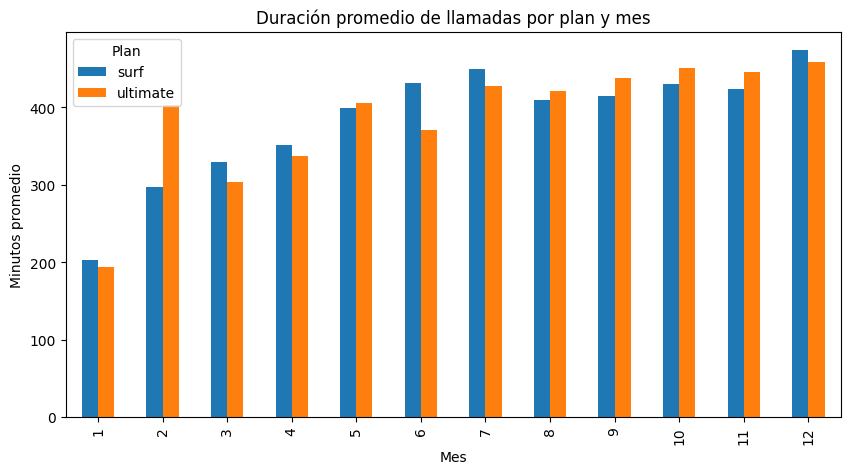

In [232]:
# Compara la duración promedio de llamadas por cada plan y por cada mes. Traza un gráfico de barras para visualizarla.

calls_avg = df.groupby(['plan', 'month'])['minutes_used'].mean().reset_index()
calls_avg_pivot = calls_avg.pivot(index='month', columns='plan', values='minutes_used')

calls_avg_pivot.plot(kind='bar', figsize=(10, 5))
plt.title('Duración promedio de llamadas por plan y mes')
plt.xlabel('Mes')
plt.ylabel('Minutos promedio')
plt.legend(title='Plan')
plt.show()

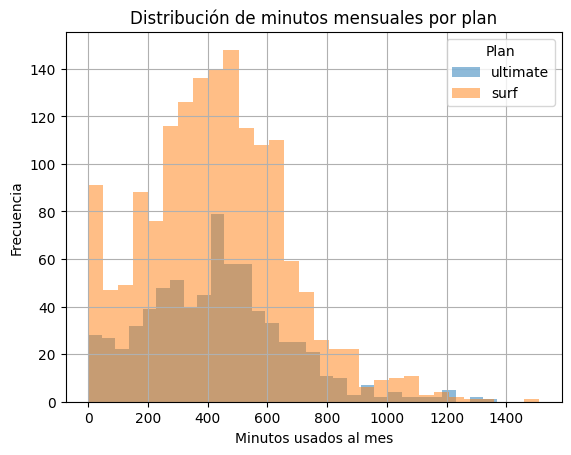

In [233]:
# Compara el número de minutos mensuales que necesitan los usuarios de cada plan. Traza un histograma.
for plan in df['plan'].unique():
    df[df['plan'] == plan]['minutes_used'].hist(alpha=0.5, bins=30, label=plan)

plt.title('Distribución de minutos mensuales por plan')
plt.xlabel('Minutos usados al mes')
plt.ylabel('Frecuencia')
plt.legend(title='Plan')
plt.show()


In [234]:
# Calcula la media y la varianza de la duración mensual de llamadas.
print(df.groupby('plan')['minutes_used'].agg(['mean', 'var']))

                mean           var
plan                              
surf      428.749523  54968.279461
ultimate  430.450000  57844.464812


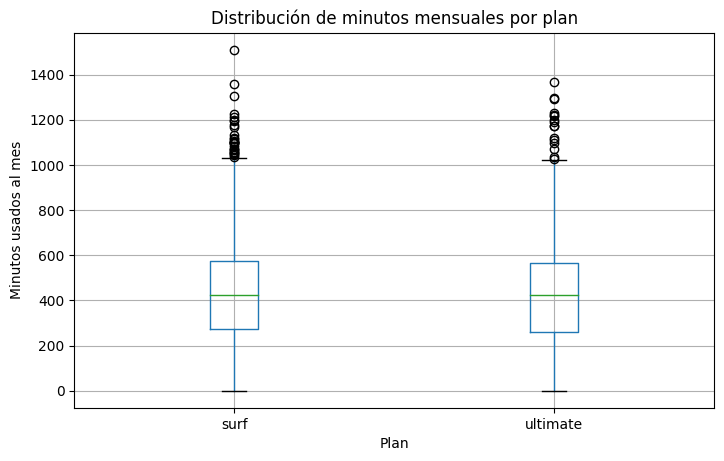

In [235]:
# Traza un diagrama de caja para visualizar la distribución de la duración mensual de llamadas
df.boxplot(column='minutes_used', by='plan', figsize=(8, 5))
plt.title('Distribución de minutos mensuales por plan')
plt.suptitle('')
plt.xlabel('Plan')
plt.ylabel('Minutos usados al mes')
plt.show()


Los usuarios de Ultimate promedian 430.45 minutos mensuales, frente a 428.75 minutos en Surf, una diferencia mínima que indica que ambos grupos de usuarios llaman una cantidad muy similar de minutos, a pesar de que Ultimate incluye un límite mucho más alto (3000 min frente a 500 en Surf). La varianza en Ultimate (57,844.46) es mayor que en Surf (54,968.28), lo que indica que el consumo entre los usuarios de este plan es ligeramente más heterogéneo. El histograma muestra que ambas distribuciones tienen forma similar, concentradas mayormente entre 200 y 600 minutos, con una cola hacia consumos más altos.

Estos resultados sugieren que, en cuanto a minutos de llamada, el comportamiento no varía significativamente según el plan contratado, el patrón de uso es prácticamente el mismo entre ambos grupos, aunque Ultimate muestra ligeramente más dispersión interna.

### Mensajes

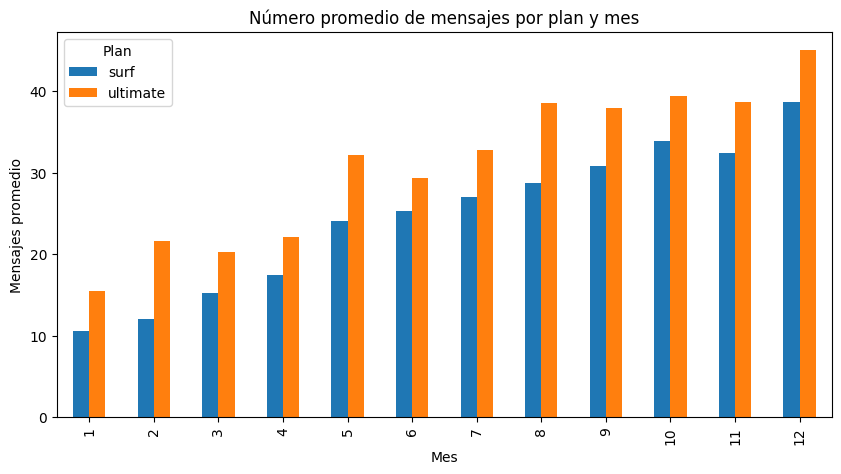

In [236]:
# Comprara el número de mensajes que tienden a enviar cada mes los usuarios de cada plan
messages_avg = df.groupby(['plan', 'month'])['messages_sent'].mean().reset_index()
messages_avg_pivot = messages_avg.pivot(index='month', columns='plan', values='messages_sent')

messages_avg_pivot.plot(kind='bar', figsize=(10, 5))
plt.title('Número promedio de mensajes por plan y mes')
plt.xlabel('Mes')
plt.ylabel('Mensajes promedio')
plt.legend(title='Plan')
plt.show()


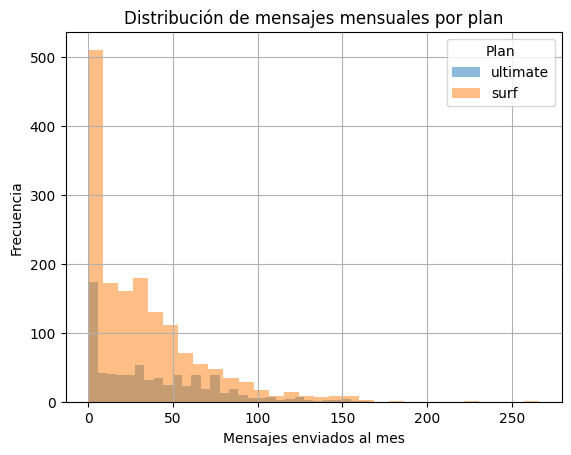

In [237]:
#Compara el número de mensajes mensuales que envían los usuarios de cada plan con histograma 
for plan in df['plan'].unique():
    df[df['plan'] == plan]['messages_sent'].hist(alpha=0.5, bins=30, label=plan)

plt.title('Distribución de mensajes mensuales por plan')
plt.xlabel('Mensajes enviados al mes')
plt.ylabel('Frecuencia')
plt.legend(title='Plan')
plt.show()

In [238]:
# Calcula la media y la varianza del número de mensajes mensuales
print(df.groupby('plan')['messages_sent'].agg(['mean', 'var']))

               mean          var
plan                            
surf      31.159568  1126.724522
ultimate  37.551389  1208.756744


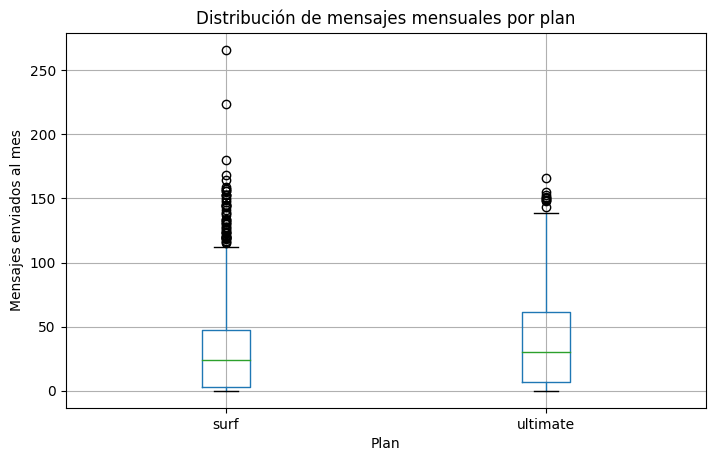

In [239]:
# Traza un diagrama de caja para visualizar la distribución de mensajes mensuales
df.boxplot(column='messages_sent', by='plan', figsize=(8, 5))
plt.title('Distribución de mensajes mensuales por plan')
plt.suptitle('')
plt.xlabel('Plan')
plt.ylabel('Mensajes enviados al mes')
plt.show()

los usuarios de Ultimate promedian 37.55 mensajes mensuales frente a 31.16 en Surf, una diferencia mas marcada que la observada en min de llamada. 
La varianza también es mayor en ultimate (1208.76 vs. 1126.72), lo que indica un consumo más heterogéneo entre sus usuarios. El histograma demuestra que ambas distribuciones estan fuertemente sesgadas a la derecha, eso indica que la mayoria de usuarios de ambos planes envian relativamente pocos mensajes al mes,mientras que una minoria envía cantidades mucho mayores.
El diagrama de caja confirma una mediana más alta en Ultimate, 30 mensajes frente a 24 de Surf, pero tambien muestra que Surf presenta mas valores atípicos con algunos usuarios que superan su límite de 50 sMS incluidos, algo que en Ultimate es menos frecuente, probablemente porque su limite de 1000 SMS rara vez se agotan.
Esto demuestra que el comportamiento de envío de mensajes si varía según el plan contratado.

### Internet

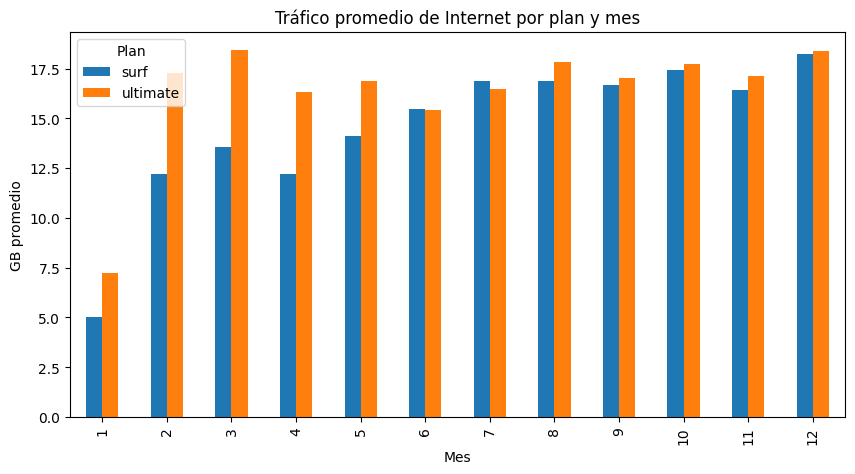

In [240]:
# Compara la cantidad de tráfico de Internet consumido por usuarios por plan
gb_avg = df.groupby(['plan', 'month'])['gb_used'].mean().reset_index()
gb_avg_pivot = gb_avg.pivot(index='month', columns='plan', values='gb_used')

gb_avg_pivot.plot(kind='bar', figsize=(10, 5))
plt.title('Tráfico promedio de Internet por plan y mes')
plt.xlabel('Mes')
plt.ylabel('GB promedio')
plt.legend(title='Plan')
plt.show()


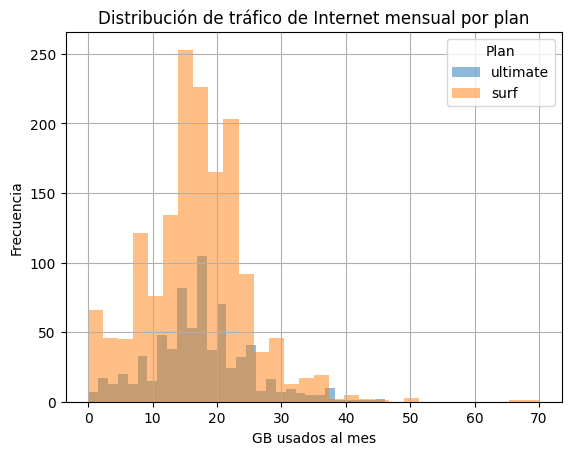

In [241]:
# Compara el volumen de tráfico de Internet mensual que consumen los usuarios de cada plan con histograma
for plan in df['plan'].unique():
    df[df['plan'] == plan]['gb_used'].hist(alpha=0.5, bins=30, label=plan)

plt.title('Distribución de tráfico de Internet mensual por plan')
plt.xlabel('GB usados al mes')
plt.ylabel('Frecuencia')
plt.legend(title='Plan')
plt.show()

In [242]:
# Calcula la media y la varianza del volumen de tráfico de Internet mensual
print(df.groupby('plan')['gb_used'].agg(['mean', 'var']))

               mean       var
plan                         
surf      16.670693  61.58360
ultimate  17.306944  58.83055


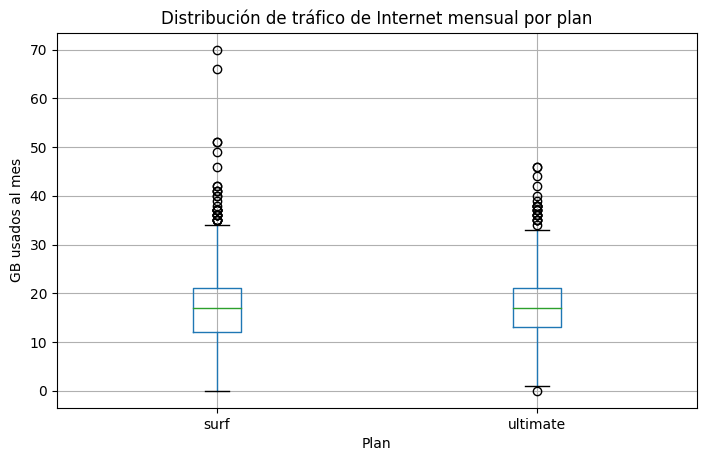

In [243]:
# Traza un diagrama de caja para visualizar la distribución del tráfico de Internet mensual
df.boxplot(column='gb_used', by='plan', figsize=(8, 5))
plt.title('Distribución de tráfico de Internet mensual por plan')
plt.suptitle('')
plt.xlabel('Plan')
plt.ylabel('GB usados al mes')
plt.show()

El consumo de datos es muy similar entre ambos planes: Ultimate promedia aproximadamente 16.81 GB mensuales frente a 16.17 GB en Surf, una diferencia menor al 5%. A diferencia de lo observado en llamadas y mensajes, aquí Surf presenta mayor varianza, lo que indica una dispersión ligeramente mayor en el consumo de datos entre sus usuarios. El histograma muestra distribuciones de forma comparable entre ambos planes, con la mayoría de usuarios concentrados entre 10 y 25 GB mensuales. El diagrama de caja confirma medianas muy similares y rangos intercuartílicos similares, aunque Surf presenta el valor atípico más extremo del conjunto, cerca de 70 GB, superando el máximo observado en Ultimate.

Estos resultados sugieren que el comportamiento de consumo de datos no varía de forma significativa según el plan contratado; el uso de internet parece depender más de hábitos individuales del usuario que del plan que tiene contratado.

## Ingreso

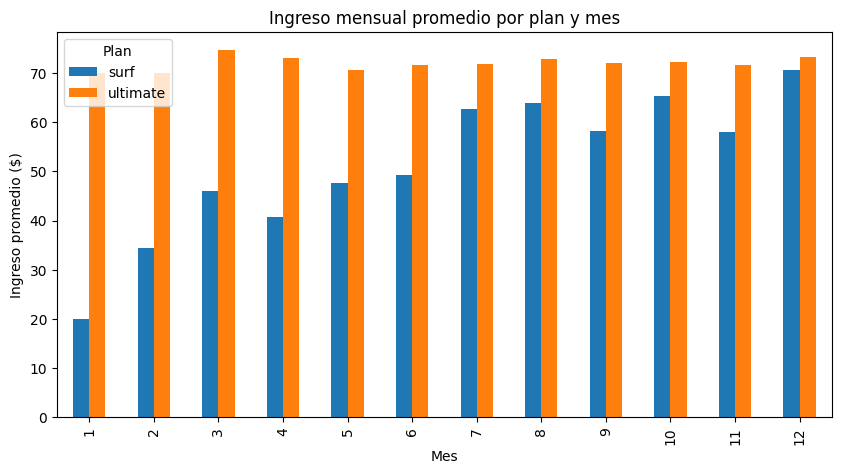

In [244]:
# Compara el ingreso mensual promedio que generan los usuarios de cada plan a lo largo del año
revenue_avg = df.groupby(['plan', 'month'])['revenue'].mean().reset_index()
revenue_avg_pivot = revenue_avg.pivot(index='month', columns='plan', values='revenue')

revenue_avg_pivot.plot(kind='bar', figsize=(10, 5))
plt.title('Ingreso mensual promedio por plan y mes')
plt.xlabel('Mes')
plt.ylabel('Ingreso promedio ($)')
plt.legend(title='Plan')
plt.show()

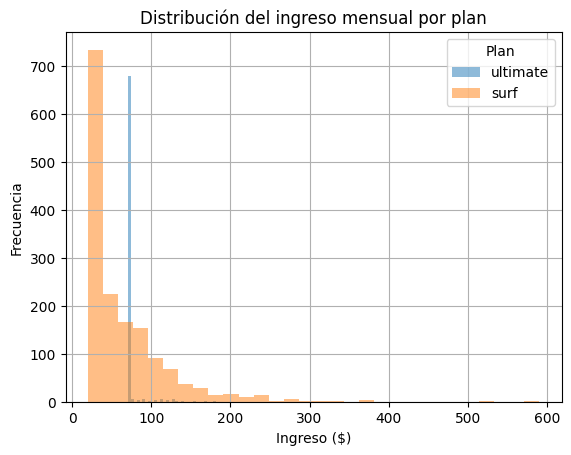

In [245]:
# Se compara el ingreso mensual que generan los usuarios de cada plan con un histograma
for plan in df['plan'].unique():
    df[df['plan'] == plan]['revenue'].hist(alpha=0.5, bins=30, label=plan)

plt.title('Distribución del ingreso mensual por plan')
plt.xlabel('Ingreso ($)')
plt.ylabel('Frecuencia')
plt.legend(title='Plan')
plt.show()

In [246]:
# Se calcula la media y la varianza del ingreso mensual por plan
print(df.groupby('plan')['revenue'].agg(['mean', 'var']))

               mean          var
plan                            
surf      60.706408  3067.835152
ultimate  72.313889   129.848486


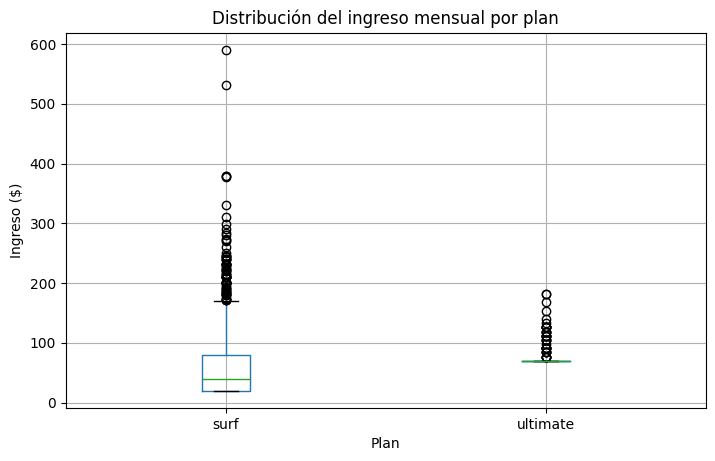

In [247]:
# Se realiza un diagrama de caja para visualizar la distribución del ingreso mensual por plan
df.boxplot(column='revenue', by='plan', figsize=(8, 5))
plt.title('Distribución del ingreso mensual por plan')
plt.suptitle('')
plt.xlabel('Plan')
plt.ylabel('Ingreso ($)')
plt.show()

El ingreso promedio de Ultimate (72.31 USD) es mayor al de Surf (60.71 USD), una diferencia de aproximadamente 11.60 USD mensuales por usuario. Sin embargo, la varianza revela un panorama mucho más sutil: Ultimate presenta una varianza notablemente baja (129.85), muestra de que su cuota fija de 70 USD rara vez se ve alterada, ya que sus límites de minutos, mensajes y datos son difíciles de exceder para el usuario promedio. Surf, en cambio, presenta una varianza muy alta (3067.84), consistente con una base de cuota baja de 20 USD que se dispara cuando los usuarios exceden sus límites, mucho más ajustados.

El histograma confirma este patrón: los ingresos de Surf se concentran mayormente entre 20 y 40 USD, pero con una cola larga de usuarios que pagan considerablemente más por excedentes, llegando hasta cerca de 600 USD mensuales, muy por encima del ingreso máximo observado en cualquier usuario de Ultimate (185 USD).

Esto sugiere que Ultimate genera un ingreso promedio más alto y estable. Sin embargo, Surf presenta usuarios de consumo alto que pueden llegar a generar ingresos individuales mayores a los de Ultimate por los cargos de excedentes. Esto evidencia que las ganancias de Surf dependen de un grupo de usuarios de alto consumo, mientras que la rentabilidad de Ultimate es más estable, aunque con un techo más bajo por usuario.


## Prueba las hipótesis estadísticas


Hipótesis nula (H₀): el ingreso promedio de los usuarios de Ultimate es igual al ingreso promedio de los usuarios de Surf. Hipótesis alternativa (H₁): el ingreso promedio de los usuarios de Ultimate es diferente al ingreso promedio de los usuarios de Surf.

Regla de decisión: se rechaza H₀ si el valor p obtenido es menor que α = 0.05; en caso contrario, no se rechaza H₀. Se eligió α = 0.05 por ser el umbral convencional en este tipo de análisis, ya que ofrece un equilibrio razonable entre el riesgo de concluir una diferencia que no existe (falso positivo) y la exigencia de evidencia necesaria para una decisión de negocio como esta.

Se utilizará una prueba t de student para dos muestras independientes (scipy.stats.ttest_ind), de dos colas, ya que no se busca probar una dirección específica de la diferencia, solo si existe o no.
Se usa equal_var=False, porque en la sección anterior se observó que las varianzas de ingreso entre ambos planes son muy distintas (129.85 en Ultimate frente a 3067.84 en Surf), por lo que no es razonable asumir varianzas iguales. Se define un nivel de significancia α = 0.05.

In [248]:
# Prueba las hipótesis
alpha = 0.05

ultimate_revenue = df[df['plan'] == 'ultimate']['revenue']
surf_revenue = df[df['plan'] == 'surf']['revenue']

results = stats.ttest_ind(ultimate_revenue, surf_revenue, equal_var=False)
print('valor p:', results.pvalue)

if results.pvalue < alpha:
    print("Rechazamos la hipótesis nula: los ingresos promedio son diferentes")
else:
    print("No podemos rechazar la hipótesis nula")


valor p: 3.1703905481135734e-15
Rechazamos la hipótesis nula: los ingresos promedio son diferentes



Hipótesis nula (H₀): el ingreso promedio de los usuarios de Ultimate es igual al ingreso promedio de los usuarios de Surf. Hipótesis alternativa (H₁): el ingreso promedio de los usuarios de Ultimate es diferente al ingreso promedio de los usuarios de Surf.

Regla de decisión: se rechaza H₀ si el valor p obtenido es menor que α = 0.05; en caso contrario, no se rechaza H₀. Se eligió α = 0.05 por ser el umbral convencional en este tipo de análisis, ya que ofrece un equilibrio razonable entre el riesgo de concluir una diferencia que no existe (falso positivo) y la exigencia de evidencia necesaria para una decisión de negocio como esta.

Se utiliza la misma prueba: t de Student de dos muestras independientes, dos colas, con equal_var=False, ya que no hay razón previa para asumir que la varianza del ingreso en NY-NJ sea igual a la del resto del país. Se mantiene α = 0.05.

In [249]:
print(users[users['city'].str.contains('New York', case=False)]['city'].unique())

['New York-Newark-Jersey City, NY-NJ-PA MSA']


In [250]:
# Prueba las hipótesis
# Prueba las hipótesis
ny_nj_revenue = df[df['is_ny_nj']]['revenue']
other_revenue = df[~df['is_ny_nj']]['revenue']

results2 = stats.ttest_ind(ny_nj_revenue, other_revenue, equal_var=False)
print('valor p:', results2.pvalue)

if results2.pvalue < alpha:
    print("Rechazamos la hipótesis nula: el ingreso en NY-NJ es diferente al del resto de regiones")
else:
    print("No podemos rechazar la hipótesis nula")


valor p: 0.0335256158853001
Rechazamos la hipótesis nula: el ingreso en NY-NJ es diferente al del resto de regiones


## Conclusión general

El análisis de comportamiento mostró que el consumo de minutos y datos es prácticamente igual entre Surf y Ultimate (428min vs. 430 min, 17,214.70mb vs. 16,558.28mb), y solo los mensajes mostraron una diferencia moderada (37.55 vs. 31.16). En las tres variables, Surf concentró los valores atípicos más extremos, con usuarios que exceden ampliamente su límite incluido.

En ingreso, Ultimate promedia 72.31 mensuales frente a 60.71 en Surf. La varianza revela por qué Ultimate es estable (129.85), porque su cuota fija de 70 rara vez se altera, Surf es muy volátil (3067.84), ya que su base de 20 se dispara con los excedentes, llegando hasta 600 en algunos usuarios.

Ambas pruebas de hipótesis confirmaron diferencias reales, el ingreso entre planes difiere de gran manera con un valor p = 3.17×10⁻¹⁵, y el ingreso en NY-NJ también difiere del resto de regiones, aunque con un margen más ajustado (valor p = 0.0335).

Se recomienda  priorizar el presupuesto de publicidad en Ultimate, ya que genera más ingreso en promedio y de forma más predecible. Como estrategia complementaria, identificar a los usuarios de Surf de alto consumo y ofrecerles migrar a Ultimate, donde la compañía aseguraría un ingreso más estable por ese segmento.